In [2]:
#インポート
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import statistics
from torch.utils.data import TensorDataset, DataLoader
import random
from tqdm import tqdm

In [3]:
def seed_everything(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

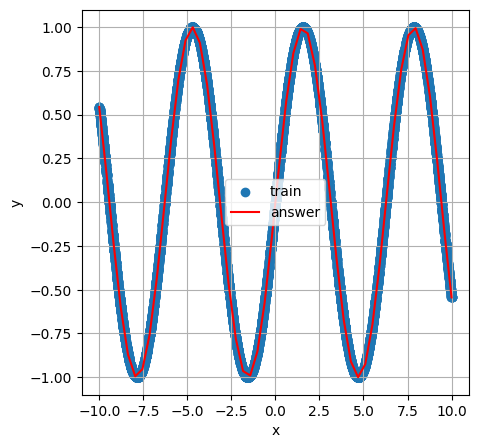

In [4]:
#データセット
seed_everything(0)
def correct(x):
    return np.sin(x)

train_x = np.random.uniform(-10, 10, size = (10000, 1))
train_t = correct(train_x)
test_x = np.random.uniform(-10, 10, size = (10000, 1))
test_t = correct(test_x)

train_x = torch.tensor(train_x, dtype=torch.float32)
train_t = torch.tensor(train_t, dtype=torch.float32)
test_x = torch.tensor(test_x, dtype=torch.float32)
test_t = torch.tensor(test_t, dtype=torch.float32)

fig = plt.figure(figsize = (5, 5))
ax = fig.add_subplot()
ax.scatter(train_x, train_t, label = "train")
ax.plot(x:=np.linspace(-10, 10), correct(x), label ="answer", c = "red")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid()

In [5]:
seed_everything(0)
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, X):
        X = self.relu(self.fc1(X))
        X = self.relu(self.fc2(X))
        X = self.relu(self.fc3(X))
        X = self.fc4(X)
        return X

In [6]:
LEARNING_RATE = 0.001
BATCH_SIZE = 512
EPOCHS = 50

In [7]:
#学習関数
seed_everything(0)
def iteration(X_batch, T_batch, model, optimizer = None):

    # 学習する場合
    if optimizer is not None:
        optimizer.zero_grad()
        Y_batch = model(X_batch)
        E_batch = loss_func(Y_batch, T_batch)
        E_batch.backward()
        optimizer.step()

    # 学習しない場合
    else:
        with torch.no_grad():
            Y_batch = model(X_batch)
            E_batch = loss_func(Y_batch, T_batch)

    return E_batch.item()

def epoch(X, T, model, optimizer = None):

    # 全データをランダムに並べ替える
    random_idx = torch.randperm(X.size(0))
    X = X[random_idx]
    T = T[random_idx]

    E = 0
    A = 0
    total_data = 0

    pb = tqdm(range(0, len(X), BATCH_SIZE))
    for idx in pb:

        # ミニバッチのデータを抽出
        X_batch = X[idx:idx + BATCH_SIZE]
        T_batch = T[idx:idx + BATCH_SIZE]

        E_batch = iteration(X_batch, T_batch, model, optimizer)

        # ミニバッチの平均になっている誤差と精度を総和に戻す
        E += E_batch * len(X_batch)
        total_data += len(X_batch)

        pb.set_postfix({"loss": E / total_data,
                        "accuracy": A / total_data})

    # 全データでの平均の誤差と精度
    E /= total_data
    A /= total_data

    return E, A

In [8]:
#Adam
seed_everything(0)
model = Model()
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE, betas = (0.9, 0.999), eps = 1e-8)
loss_func =  nn.MSELoss()

Adam_train_loss_history = list()
Adam_test_loss_history = list()
Adam_train_acuracy_history = list()
Adam_test_acuracy_history = list()

E, A = epoch(train_x, train_t, model)
Adam_train_loss_history.append(E)
Adam_train_acuracy_history.append(A)
E, A = epoch(test_x, test_t, model)
Adam_test_loss_history.append(E)
Adam_test_acuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    E, A = epoch(train_x, train_t, model, optimizer)
    Adam_train_loss_history.append(E)
    Adam_train_acuracy_history.append(A)

    E, A = epoch(test_x, test_t, model)
    Adam_test_loss_history.append(E)
    Adam_test_acuracy_history.append(A)

with torch.no_grad():
    Adam_Y = model(test_x)

100%|██████████| 20/20 [00:00<00:00, 284.54it/s, loss=0.471, accuracy=0]


epoch; 1


100%|██████████| 20/20 [00:00<00:00, 260.41it/s, loss=0.42, accuracy=0]


epoch; 2


100%|██████████| 20/20 [00:00<00:00, 225.73it/s, loss=0.366, accuracy=0]


...

100%|██████████| 20/20 [00:00<00:00, 319.16it/s, loss=0.000161, accuracy=0]


epoch; 49


100%|██████████| 20/20 [00:00<00:00, 889.25it/s, loss=0.00013, accuracy=0]


epoch; 50


100%|██████████| 20/20 [00:00<00:00, 229.13it/s, loss=0.000119, accuracy=0]


In [9]:
#ADINA
seed_everything(0)
class ADINA(torch.optim.Optimizer):
    def __init__(self, params, lr = 0.001, beta_1 = 0.9, beta_2 = 0.9, a = 0.1, b = 0.01, c = 1):
        defaults = {"lr":lr, "beta_1":beta_1, "beta_2":beta_2, "a":a, "b":b}
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            beta_1 = group["beta_1"]
            beta_2 = group["beta_2"]
            a = group["a"]
            b = group["b"]

            for w in group["params"]:
                if w.grad is None:
                    continue

                state = self.state[w]
                if len(state) == 0:
                    state["m"] = torch.zeros_like(w)
                    state["g"] = torch.zeros_like(w)
                    state["v"] = torch.zeros_like(w)
                    state["step"] = 0
                state["step"] += 1
                grad = w.grad
                m = state["m"]
                v = state["v"]
                step = state["step"]

                m.mul_(beta_1).add_(grad * (1-a*b) / a , alpha = 1.0 - beta_1)
                g = m / (1 - beta_1 ** step) + b * grad
                v.mul_(beta_2).add_(g*g , alpha = 1 - beta_2)
                w.sub_(g / (v / (1 - beta_2 ** step) + 1e-8)**0.5 , alpha = lr)

seed_everything(0)
model = Model()
optimizer = ADINA(model.parameters(), lr = LEARNING_RATE, beta_1 = 0.9, beta_2 = 0.9, a = 0.1, b = 0.01, c = 1)
loss_func = loss_func

ADINA_train_loss_history = list()
ADINA_test_loss_history = list()
ADINA_train_acuracy_history = list()
ADINA_test_acuracy_history = list()

E, A = epoch(train_x, train_t, model)
ADINA_train_loss_history.append(E)
ADINA_train_acuracy_history.append(A)
E, A = epoch(test_x, test_t, model)
ADINA_test_loss_history.append(E)
ADINA_test_acuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    E, A = epoch(train_x, train_t, model, optimizer)
    ADINA_train_loss_history.append(E)
    ADINA_train_acuracy_history.append(A)

    E, A = epoch(test_x, test_t, model)
    ADINA_test_loss_history.append(E)
    ADINA_test_acuracy_history.append(A)

with torch.no_grad():
    ADINA_Y = model(test_x)

100%|██████████| 20/20 [00:00<00:00, 466.44it/s, loss=0.471, accuracy=0]


epoch; 1


100%|██████████| 20/20 [00:00<00:00, 246.86it/s, loss=0.402, accuracy=0]


epoch; 2


100%|██████████| 20/20 [00:00<00:00, 214.88it/s, loss=0.331, accuracy=0]


...

100%|██████████| 20/20 [00:00<00:00, 138.24it/s, loss=0.00322, accuracy=0]


epoch; 49


100%|██████████| 20/20 [00:00<00:00, 374.88it/s, loss=0.00493, accuracy=0]


epoch; 50


100%|██████████| 20/20 [00:00<00:00, 412.62it/s, loss=0.00317, accuracy=0]


In [10]:
#Schedule-Free_ADINA
seed_everything(0)
class ScheduleFree_ADINA(torch.optim.Optimizer):
    def __init__(self, params, lr=LEARNING_RATE, lamda=0.3, beta1 =0.9, beta2 = 0.999, a = 0.1, b = 0.01, eps = 1e-8):
        defaults = {"lr":lr, "lamda":lamda, "beta1":beta1, "beta2":beta2, "a":a, "b":b, "eps":eps}
        super().__init__(params, defaults)
        self.train_mode = True

    def train(self):
        if not self.train_mode:
            for group in self.param_groups:
                lamda = group["lamda"]
                for p in group["params"]:
                    if p.grad is None:
                        continue
                    state = self.state[p]
                    p.data.copy_(state["w"])
                    p.data.lerp_(state["x"], lamda)
            self.train_mode = True

    def eval(self):
        if self.train_mode:
            for group in self.param_groups:
                for p in group["params"]:
                    if p.grad is None:
                        continue
                    state = self.state[p]
                    p.data.copy_(state["x"])
            self.train_mode = False

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            lamda = group["lamda"]
            beta1 = group["beta1"]
            beta2 = group["beta2"]
            a = group["a"]
            b = group["b"]
            eps = group["eps"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                state = self.state[p]
                if len(state) == 0:
                    state["w"] = p.data.clone()
                    state["x"] = p.data.clone()
                    state["g"] = torch.zeros_like(p.data)
                    state["v"] = torch.zeros_like(p.data)
                    state["k"] = 0

                state["k"] += 1
                k = state["k"]

                w = state["w"]
                x = state["x"]
                g = state["g"]
                v = state["v"]
                grad = p.grad

                g.mul_(beta1).add_(grad * ((1 - a*b) / a), alpha = 1.0 - beta1)
                v.mul_(beta2).add_(grad**2, alpha = 1.0 - beta2)
                w.sub_((g / (1 - beta1**(k+1)) + b * grad) / ((v / (1-beta2**(k+1)))**0.5 + eps), alpha = lr)
                x.lerp_(w, 1/(k+1))

                if self.train_mode:
                    p.data.copy_(w)
                    p.data.lerp_(x, lamda)
                else:
                    p.data.copy_(x)

        return loss


model = Model()
optimizer = ScheduleFree_ADINA(model.parameters(), lr = LEARNING_RATE)
loss_func = loss_func

SF_ADINA_train_loss_history = list()
SF_ADINA_test_loss_history = list()
SF_ADINA_train_acuracy_history = list()
SF_ADINA_test_acuracy_history = list()

# 初期評価（evalモード）
optimizer.eval()
E, A = epoch(train_x, train_t, model)
SF_ADINA_train_loss_history.append(E)
SF_ADINA_train_acuracy_history.append(A)

E, A = epoch(test_x, test_t, model)
SF_ADINA_test_loss_history.append(E)
SF_ADINA_test_acuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")

    #学習
    optimizer.train()
    E, A = epoch(train_x, train_t, model, optimizer)
    SF_ADINA_train_loss_history.append(E)
    SF_ADINA_train_acuracy_history.append(A)

    #評価
    optimizer.eval()
    E, A = epoch(test_x, test_t, model)
    SF_ADINA_test_loss_history.append(E)
    SF_ADINA_test_acuracy_history.append(A)

with torch.no_grad():
    SF_ADINA_Y = model(test_x)

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 381.13it/s, loss=0.471, accuracy=0]


epoch; 1


100%|██████████| 20/20 [00:00<00:00, 401.20it/s, loss=0.408, accuracy=0]


epoch; 2


...

100%|██████████| 20/20 [00:00<00:00, 226.87it/s, loss=0.000981, accuracy=0]


epoch; 49


100%|██████████| 20/20 [00:00<00:00, 475.12it/s, loss=0.000931, accuracy=0]


epoch; 50


100%|██████████| 20/20 [00:00<00:00, 383.29it/s, loss=0.000884, accuracy=0]


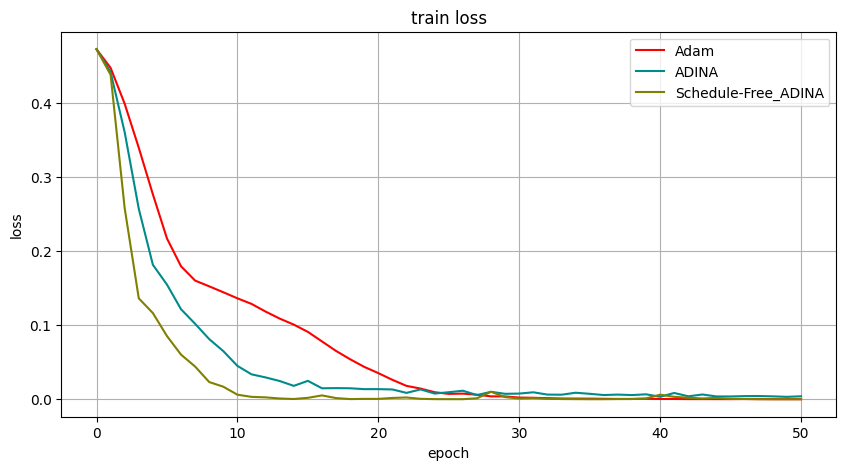

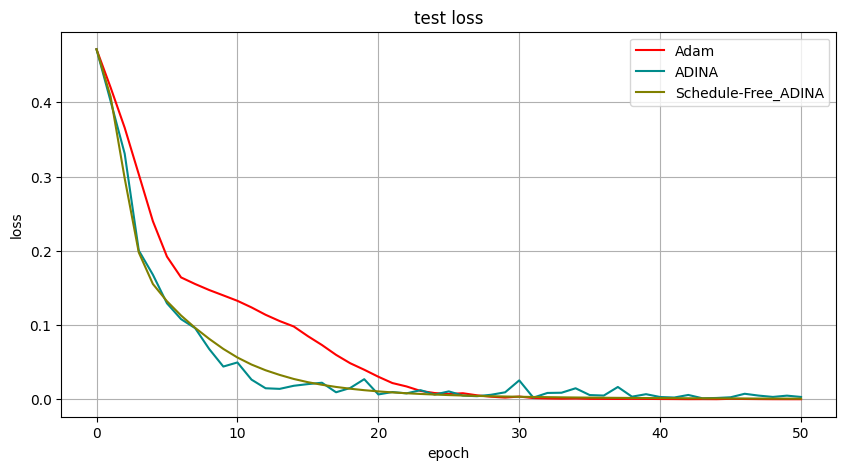

In [16]:
fig = plt.figure(figsize = (10, 5))
ax = fig.add_subplot()
ax.plot(Adam_train_loss_history, label = "Adam", c = 'red')
ax.plot(ADINA_train_loss_history, label = "ADINA", c = 'darkcyan')
ax.plot(SF_ADINA_train_loss_history, label = "Schedule-Free_ADINA", c = 'olive')
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("train loss")
ax.grid()
ax.legend()

fig = plt.figure(figsize = (10, 5))
ax = fig.add_subplot()
ax.plot(Adam_test_loss_history, label = "Adam", c = 'red')
ax.plot(ADINA_test_loss_history, label = "ADINA", c = 'darkcyan')
ax.plot(SF_ADINA_test_loss_history, label = "Schedule-Free_ADINA", c = 'olive')
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("test loss")
ax.grid()
ax.legend()